# Some Common Derivatives — Quadratics

A guided notebook transcribed and expanded from the Coursera
*Calculus for Machine Learning and Data Science* lecture on the derivative of a
**quadratic** (Week 1 — Derivatives and Optimization).

This notebook explains:

- the parabola $f(x) = x^2$ and the sign of its slope
- estimating the tangent slope at $x = 1$ by shrinking $\Delta x$ (slopes $\to 2$)
- the formal derivation $\dfrac{\Delta f}{\Delta x} = 2x + \Delta x \to 2x$
- the result $\dfrac{d}{dx}x^2 = 2x$, verified with SymPy, plus the general quadratic

This notebook follows the repository `GUIDELINES.md` template and continues directly from
*Some Common Derivatives — Lines*.

## 1. The simplest quadratic

The simplest quadratic is the parabola $y = x^2$. Looking at its tangents:

- to the **left** of the $y$-axis the slopes are **negative**,
- to the **right** they are **positive**,
- at $x = 0$ the slope is $0$ (the bottom of the parabola).

This already hints the derivative grows with $x$.

## 2. Estimating the slope at $x = 1$

The derivative is $\displaystyle \lim_{\Delta x \to 0}\frac{\Delta f}{\Delta x}$, with
$\Delta f = (x+\Delta x)^2 - x^2$.

At $x = 1$ (where $y = 1$), let's shrink $\Delta x$ and watch the secant slope.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

def f(x):
    return x**2

x0 = 1.0
print(f"{'Δx':>8} | {'Δf':>10} | {'slope Δf/Δx':>12}")
print("-" * 36)
for dx in [1, 1/2, 1/4, 1/8, 1/16, 1/1000]:
    df = f(x0 + dx) - f(x0)
    print(f"{dx:>8.4f} | {df:>10.5f} | {df/dx:>12.5f}")
print("\n-> the slope approaches 2 = 2*1, the tangent slope at x=1.")

      Δx |         Δf |  slope Δf/Δx
------------------------------------
  1.0000 |    3.00000 |      3.00000
  0.5000 |    1.25000 |      2.50000
  0.2500 |    0.56250 |      2.25000
  0.1250 |    0.26562 |      2.12500
  0.0625 |    0.12891 |      2.06250
  0.0010 |    0.00200 |      2.00100

-> the slope approaches 2 = 2*1, the tangent slope at x=1.


## 3. The formal derivation

$$
\frac{\Delta f}{\Delta x}
= \frac{(x+\Delta x)^2 - x^2}{\Delta x}
= \frac{x^2 + 2x\,\Delta x + (\Delta x)^2 - x^2}{\Delta x}.
$$

The $x^2$ terms cancel; dividing the rest by $\Delta x$:

$$
\frac{\Delta f}{\Delta x} = 2x + \Delta x .
$$

As $\Delta x \to 0$ the last term vanishes, leaving

$$
\boxed{\;\frac{d}{dx}\,x^2 = 2x.\;}
$$

In [2]:
x, dx = sp.symbols('x Delta_x')
ratio = ((x + dx)**2 - x**2) / dx
print("Δf/Δx =", sp.expand(ratio))                 # 2*x + Delta_x
print("limit Δx->0 =", sp.limit(ratio, dx, 0))     # 2*x
print("SymPy d/dx (x²) =", sp.diff(x**2, x))

Δf/Δx = Delta_x + 2*x
limit Δx->0 = 2*x
SymPy d/dx (x²) = 2*x


## 4. The general quadratic

The same method gives the derivative of any quadratic. For
$f(x) = ax^2 + bx + c$:

$$
f'(x) = 2ax + b .
$$

In [3]:
a, b, c = sp.symbols('a b c')
print("d/dx (a x² + b x + c) =", sp.diff(a*x**2 + b*x + c, x))

for expr in [x**2, 3*x**2, x**2 + 2*x + 1, -2*x**2 + 5*x]:
    print(f"f(x) = {str(expr):>14}   ->   f'(x) = {sp.diff(expr, x)}")

d/dx (a x² + b x + c) = 2*a*x + b
f(x) =           x**2   ->   f'(x) = 2*x
f(x) =         3*x**2   ->   f'(x) = 6*x
f(x) = x**2 + 2*x + 1   ->   f'(x) = 2*x + 2
f(x) =  -2*x**2 + 5*x   ->   f'(x) = 5 - 4*x


## 5. Visualizing

**Left:** secant lines at $x=1$ rotating into the tangent of slope $2$.
**Right:** $f(x)=x^2$ and its derivative $f'(x)=2x$ (negative left of $0$, positive right).

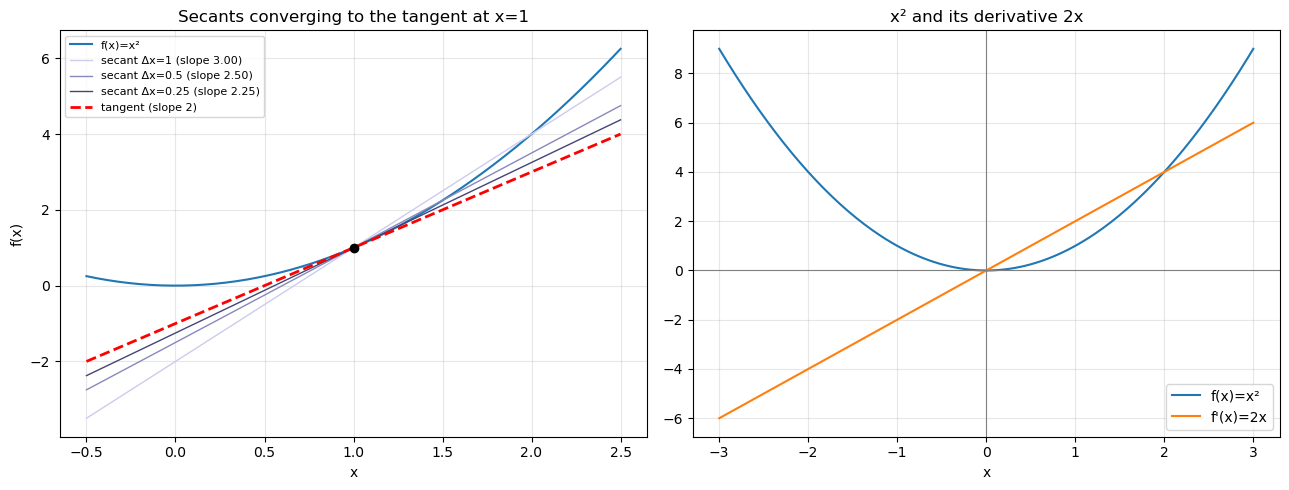

In [4]:
xs = np.linspace(-0.5, 2.5, 200)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(xs, xs**2, label="f(x)=x²")
for dx, col in zip([1, 0.5, 0.25], ["#cce", "#88b", "#447"]):
    slope = ((1+dx)**2 - 1)/dx
    axes[0].plot(xs, 1 + slope*(xs-1), color=col, lw=1, label=f"secant Δx={dx} (slope {slope:.2f})")
axes[0].plot(xs, 1 + 2*(xs-1), "r--", lw=2, label="tangent (slope 2)")
axes[0].plot(1, 1, "ko")
axes[0].set_title("Secants converging to the tangent at x=1")
axes[0].set_xlabel("x"); axes[0].set_ylabel("f(x)")
axes[0].grid(True, alpha=0.3); axes[0].legend(fontsize=8)

xs2 = np.linspace(-3, 3, 200)
axes[1].plot(xs2, xs2**2, label="f(x)=x²")
axes[1].plot(xs2, 2*xs2, label="f'(x)=2x")
axes[1].axhline(0, color="gray", lw=0.8); axes[1].axvline(0, color="gray", lw=0.8)
axes[1].set_title("x² and its derivative 2x")
axes[1].set_xlabel("x"); axes[1].grid(True, alpha=0.3); axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Exercises

### Basic
1. What is the derivative of $f(x) = x^2$?
2. What is the slope of the tangent to $y = x^2$ at $x = 1$? At $x = 0$? At $x = -2$?

### Intermediate
3. Estimate the slope of $x^2$ at $x = 3$ numerically with a small $\Delta x$, and compare
   to $2x$.
4. Differentiate $f(x) = 3x^2 + 2x + 1$.

### Advanced
5. Using the limit definition, derive $f'(x)$ for $f(x) = ax^2 + bx + c$.
6. For $f(x) = x^2$, at what $x$ is the slope zero, and what does that point represent?

## 7. Solutions / Checks

In [5]:
x = sp.symbols('x')

# 2.
for p in (1, 0, -2):
    print(f"2. slope of x² at x={p}: {sp.diff(x**2, x).subs(x, p)}")

# 3.
dx = 1e-6
print(f"3. numeric slope at 3: {((3+dx)**2-3**2)/dx:.4f}  (exact 2*3=6)")

# 4.
print("4. d/dx (3x²+2x+1) =", sp.diff(3*x**2 + 2*x + 1, x))

# 5.
a, b, c, h = sp.symbols('a b c h')
f = a*x**2 + b*x + c
print("5. limit definition:", sp.simplify(sp.limit((f.subs(x, x+h) - f)/h, h, 0)))

print("6. slope zero at x=0 -> the vertex (minimum) of the parabola.")

2. slope of x² at x=1: 2
2. slope of x² at x=0: 0
2. slope of x² at x=-2: -4
3. numeric slope at 3: 6.0000  (exact 2*3=6)
4. d/dx (3x²+2x+1) = 6*x + 2


5. limit definition: 2*a*x + b
6. slope zero at x=0 -> the vertex (minimum) of the parabola.


## 8. Conclusion

- For the parabola $f(x) = x^2$, shrinking $\Delta x$ at $x = 1$ gives slopes
  $3, 2.5, 2.25, \dots \to 2$.
- Formally $\dfrac{\Delta f}{\Delta x} = 2x + \Delta x \to 2x$, so
  $\dfrac{d}{dx}x^2 = 2x$.
- More generally $\dfrac{d}{dx}(ax^2 + bx + c) = 2ax + b$.
- The derivative is negative left of the vertex, zero at the vertex, and positive to the
  right — next come higher-degree polynomials.

## Appendix — Source transcript

Transcribed with OpenAI Whisper (`small.en`) from a locally downloaded video
(`~/Downloads/index (8).mp4`), the Coursera *Calculus for Machine Learning and Data
Science* (Week 1) lecture **some common derivatives — quadratics**. Key spoken points,
lightly cleaned:

> Take the parabola $y = x^2$. Its slopes are negative left of the $y$-axis and positive to
> the right. The derivative is $\Delta f/\Delta x$ as $\Delta x \to 0$, with $\Delta f =
> (x+\Delta x)^2 - x^2$. At $x = 1$ ($y = 1$): $\Delta x = 1$ gives $\Delta f = 4 - 1 = 3$,
> slope $3$; $\Delta x = 1/2$ gives slope $2.5$; $\Delta x = 1/4$ gives $2.25$; then
> $2.125$, $2.0625$, and at $\Delta x = 1/1000$, $2.001$ — heading to $2$, which is
> $2\times 1$. Formally, $\Delta f/\Delta x = ((x+\Delta x)^2 - x^2)/\Delta x = 2x + \Delta
> x$, and as $\Delta x \to 0$ this is $2x$. So for $f(x) = x^2$, $f'(x) = 2x$.